# Hari 1 · Sesi 2–3 — EDA (Exploratory Data Analysis)
EDA = **kenalan dengan data sebelum bikin model**. Di kompetisi, EDA menjawab 5 pertanyaan:
1. Datanya sebesar apa, kolomnya apa saja, tipenya apa?
2. Mana yang kosong (missing)? Seberapa banyak?
3. Targetnya seperti apa? Seimbang atau tidak?
4. Kolom mana yang kelihatannya berpengaruh ke target?
5. Ada yang aneh? (outlier, duplikat, kolom ID/teks yang tidak berguna)

Notebook ini mengikuti **Resep 12 Langkah** di web Dojo: langkah 3 sampai 9 adalah EDA.

**Cara kerja tiap latihan**
1. Baca **Contoh**, lalu jalankan: klik selnya, tekan `Shift + Enter`.
2. Kerjakan **Latihan**: ganti `____` (atau `...`) dengan kode yang benar, lalu jalankan. Baris `cek(...)` di bawahnya langsung bilang ✅ atau ❌.
3. Mentok? Jalankan `hint('1.2')` di sel baru (bisa dipanggil berkali-kali, petunjuknya makin jelas). Masih mentok, baru `jawaban('1.2')`. Setelah lihat jawaban, **ketik ulang sendiri, jangan copy-paste**.
4. Kalau muncul error merah, baca **baris terakhirnya** dulu. Di bawahnya ada **💡 PENJELASAN DOJO** dalam bahasa Indonesia.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')   # sembunyikan warning (warning bukan error)
from cek import cek, hint, jawaban, progres

train = pd.read_csv('data/titanic/train.csv')
test = pd.read_csv('data/titanic/test.csv')
print('train:', train.shape, '| test:', test.shape)

train: (712, 12) | test: (179, 11)


## Langkah 3 — Kenalan: tipe kolom & statistik ringkas

In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          575 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        160 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.9+ KB


In [24]:
# Statistik kolom ANGKA: count, mean, std, min, kuartil (25%, 50%=median, 75%), max
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,712.000000,575.000000,712.000000,712.000000,712.000000
mean,444.405899,0.383427,2.308989,29.807687,0.492978,0.390449,31.819826
std,257.465527,0.486563,0.833563,14.485211,1.060720,0.838134,48.059104
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,439.500000,0.000000,3.000000,28.500000,0.000000,0.000000,14.454200
75%,667.250000,1.000000,3.000000,39.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
# Statistik kolom TEKS: count, unique (jumlah nilai unik), top (paling sering), freq
train.describe(exclude='number')

,Name,Sex,Ticket,Cabin,Embarked
count,712,712,712,160,710
unique,712,2,571,127,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,459,6,4,516


**Cara baca `describe()`:**
- Lihat **min & max**. Ada nilai mustahil? (umur 0 atau 150, harga negatif, tahun 0)
- Bandingkan **mean vs 50% (median)**. Kalau mean jauh lebih besar, datanya **miring ke kanan** karena ada nilai besar ekstrem. Contoh: `Fare`, mean 31.8 sedangkan median 14.5.

In [26]:
# Pisahkan nama kolom angka dan teks. Cara ini aman di pandas 2 maupun 3
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(exclude='number').columns.tolist()
print('Numerik    :', num_cols)
print('Kategorikal:', cat_cols)

Numerik    : ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Kategorikal: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


**Latihan 2.1** — Simpan daftar kolom **numerik** ke `kolom_angka` (sebagai list).

In [27]:
kolom_angka = train.select_dtypes(include="number").columns.tolist()
cek('2.1', kolom_angka)

✅ [2.1] Benar! Keren!


**Latihan 2.2** — Simpan daftar kolom **non-numerik** ke `kolom_teks`.

In [28]:
kolom_teks = train.select_dtypes(exclude='number').columns.tolist()
cek('2.2', kolom_teks)

✅ [2.2] Benar! Rapi!


## Langkah 4 — Missing value
**Aturan praktis** (bukan hukum mati):
| Persen kosong | Biasanya diapakan |
|---|---|
| < 5% | isi saja (median untuk angka, modus untuk teks) |
| 5–60% | isi, dan pertimbangkan kolom penanda "dulu kosong" |
| > 60% | buang kolomnya, atau ubah jadi "ada/tidak ada" |

In [29]:
# Jumlah kosong per kolom
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64

In [30]:
# Persentase kosong per kolom, urut dari terbesar
(train.isnull().mean() * 100).sort_values(ascending=False)

Cabin          77.528090
Age            19.241573
Embarked        0.280899
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

**Latihan 2.3** — Hitung **jumlah** missing per kolom, simpan ke `jumlah_kosong`.

In [31]:
jumlah_kosong = train.isnull().sum()
cek('2.3', jumlah_kosong)

✅ [2.3] Benar! Nah, gitu!


**Latihan 2.4** — Hitung **persentase** missing per kolom (skala 0–100), simpan ke `persen_kosong`.

In [32]:
persen_kosong = train.isnull().mean() * 100
cek('2.4', persen_kosong)

✅ [2.4] Benar! Mantap!


**Latihan 2.5** — Dari `jumlah_kosong`, ambil **hanya** kolom yang ada missing-nya (jumlah > 0). Simpan ke `ada_kosong`.

In [33]:
ada_kosong = jumlah_kosong[jumlah_kosong > 0]
cek('2.5', ada_kosong)

✅ [2.5] Benar! Gas terus!


In [34]:
# JANGAN LUPA cek TEST juga: di sini Fare kosong 1 di test, padahal di train lengkap!
# Kalau tidak diisi, model bakal error waktu memprediksi test.
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             40
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          135
Embarked         0
dtype: int64

## Langkah 5 — Duplikat

In [35]:
print('Baris duplikat:', train.duplicated().sum())
# Kalau ada: train = train.drop_duplicates()

Baris duplikat: 0


**Latihan 2.6** — Hitung jumlah baris duplikat, simpan ke `n_duplikat`.

In [41]:
n_duplikat = train.duplicated().sum()
cek('2.6', n_duplikat)

✅ [2.6] Benar! Rapi!


## Langkah 6 — Target

Survived
0    439
1    273
Name: count, dtype: int64
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


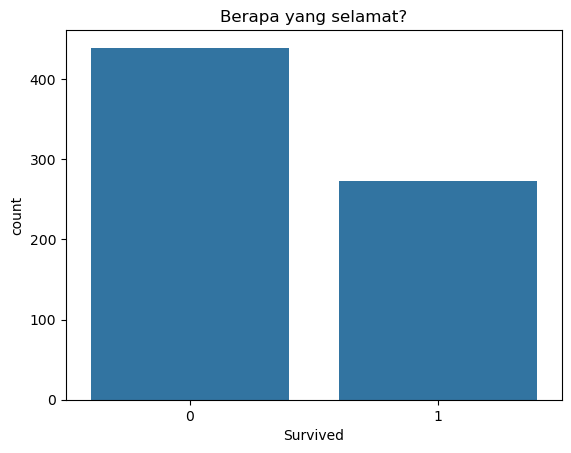

In [42]:
print(train['Survived'].value_counts())
print(train['Survived'].value_counts(normalize=True))
sns.countplot(data=train, x='Survived')
plt.title('Berapa yang selamat?')
plt.show()

Kalau satu kelas jauh lebih banyak (misal 90% vs 10%), namanya **imbalanced**, dan akurasi bisa menipu. Di sini 62% vs 38%, masih aman.

**Baseline:** kalau model cuma menebak "0" untuk semua orang, akurasinya ≈ 0.62. **Model kamu wajib lebih baik dari angka ini.** Kalau tidak, ada yang salah.

**Latihan 2.7** — Hitung **akurasi tebak mayoritas** = proporsi kelas terbanyak. Simpan ke `baseline`.

In [45]:
baseline = train['Survived'].value_counts(normalize=True).max()
cek('2.7', baseline)

✅ [2.7] Benar! Lanjut!


## Langkah 7 — Kolom angka: sebaran & outlier

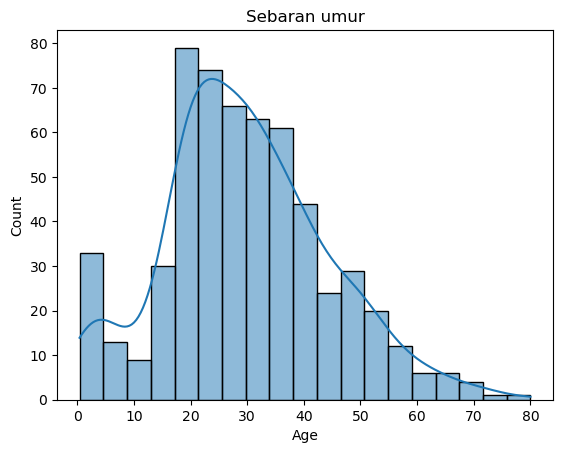

In [46]:
sns.histplot(data=train, x='Age', kde=True)
plt.title('Sebaran umur')
plt.show()

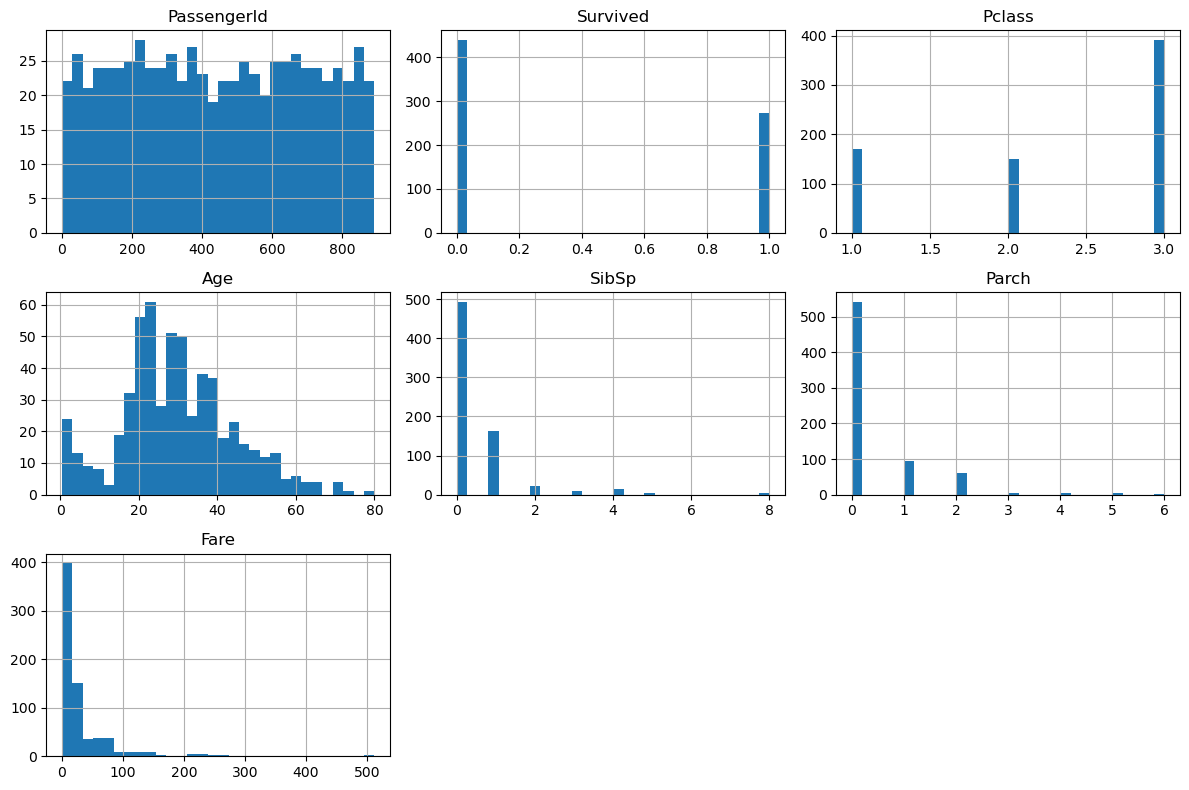

In [49]:
# Semua kolom angka sekaligus
train[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

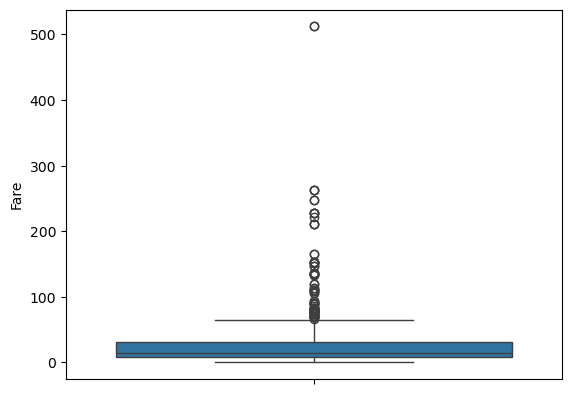

In [51]:
# Boxplot: titik-titik di luar "kumis" = outlier (nilai ekstrem)
sns.boxplot(data=train, y='Fare')
plt.show()

In [52]:
# Menghitung outlier dengan aturan IQR
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
print('Batas atas:', batas_atas)
print('Jumlah outlier Fare:', (train['Fare'] > batas_atas).sum())

Batas atas: 65.6563
Jumlah outlier Fare: 91


**Latihan 2.8** — Buat histogram kolom `Fare`. Simpan hasil `sns.histplot(...)` ke variabel `ax`.

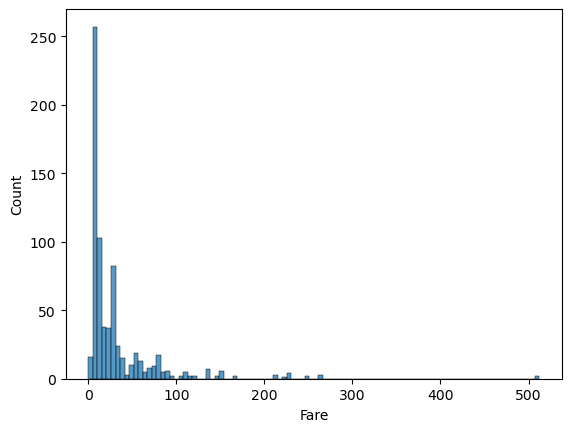

✅ [2.8] Benar! Mantap!


In [54]:
ax = sns.histplot(data=train, x='Fare')
plt.show()
cek('2.8', ax)

**Latihan 2.9** — Hitung jumlah outlier `Age` dengan aturan IQR (di bawah batas bawah **atau** di atas batas atas).

In [55]:
Q1 = train['Age'].quantile(0.25)
Q3 = train['Age'].quantile(0.75)
IQR = Q3 - Q1
bawah = Q1 - 1.5 * IQR
atas = Q3 + 1.5 * IQR
n_outlier_age = ((train['Age'] < bawah) | (train['Age'] > atas)).sum()
cek('2.9', n_outlier_age)

✅ [2.9] Benar! Nah, gitu!


> **Outlier tidak selalu harus dibuang.** Tiket mahal di Titanic itu nyata (kelas 1). Buang/ubah outlier hanya kalau nilainya **mustahil** (umur 150, luas tanah 10x lipat karena salah ketik). Model pohon seperti Random Forest cukup tahan outlier.

## Langkah 8 — Kolom teks (kategorikal)

In [56]:
train['Embarked'].value_counts()

Embarked
S    516
C    139
Q     55
Name: count, dtype: int64

In [57]:
# Jumlah nilai unik tiap kolom teks. Yang ratusan (Name, Ticket) = teks bebas/ID, biasanya dibuang
train[cat_cols].nunique()

Name        712
Sex           2
Ticket      571
Cabin       127
Embarked      3
dtype: int64

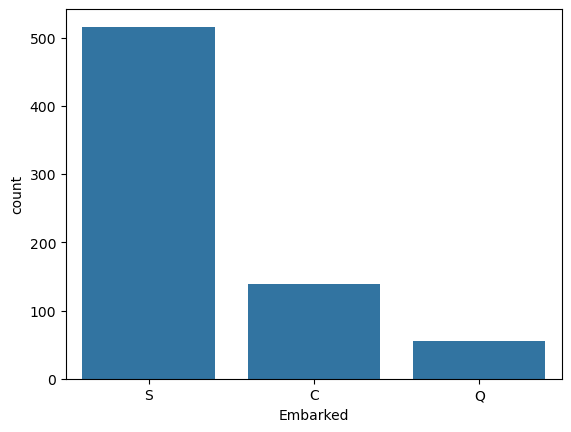

In [92]:
sns.countplot(data=train, x='Embarked')
plt.show()

**Latihan 2.10** — Hitung jumlah nilai unik tiap kolom teks (`cat_cols`), simpan ke `unik_teks`.

In [64]:
unik_teks = train[cat_cols].nunique()
cek('2.10', unik_teks)



✅ [2.10] Benar! Rapi!


## Langkah 9 — Hubungan fitur dengan target ⭐ (bagian terpenting EDA)
- **Kategori vs target**: `groupby(kategori)[target].mean()` atau `pd.crosstab(...)`
- **Angka vs target**: `groupby(target)[angka].mean()` atau boxplot

In [ ]:
# Peluang selamat per jenis kelamin
train.groupby('Sex')['Survived'].mean()

Sex
female    0.743083
male      0.185185
Name: Survived, dtype: float64

In [66]:
# crosstab = tabel silang. normalize='index' -> persen per baris
pd.crosstab(train['Pclass'], train['Survived'], normalize='index')

Survived,0,1
Pclass,,
1,0.350877,0.649123
2,0.553333,0.446667
3,0.757033,0.242967


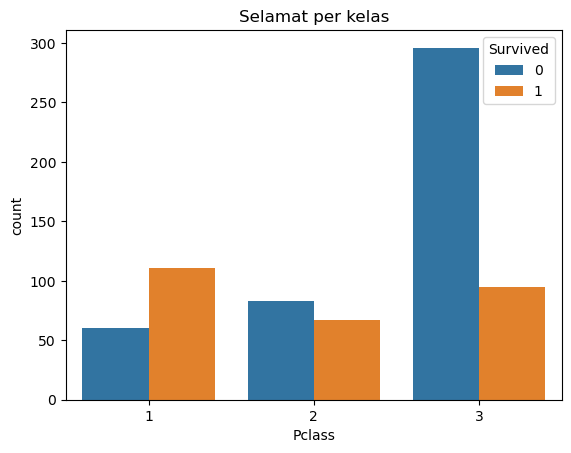

In [67]:
sns.countplot(data=train, x='Pclass', hue='Survived')
plt.title('Selamat per kelas')
plt.show()

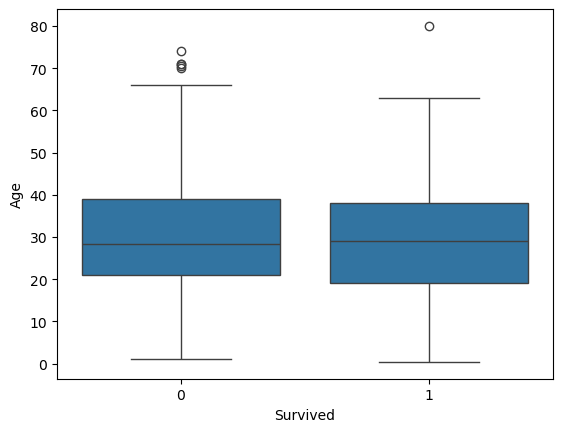

In [68]:
# Angka vs target: bandingkan sebaran umur di kelompok selamat dan tidak
sns.boxplot(data=train, x='Survived', y='Age')
plt.show()

In [69]:
train.groupby('Survived')[['Age', 'Fare']].mean()

,Age,Fare
Survived,,
0,30.814327,21.386094
1,28.330129,48.597880


**Latihan 2.11** — Hitung peluang selamat per pelabuhan `Embarked`, simpan ke `selamat_per_pelabuhan`.

In [70]:
selamat_per_pelabuhan = train.groupby('Embarked')['Survived'].mean()
cek('2.11', selamat_per_pelabuhan)

✅ [2.11] Benar! Gas terus!


**Latihan 2.12** — Hitung rata-rata `Fare` untuk yang selamat vs tidak, simpan ke `fare_per_target`.

In [71]:
fare_per_target = train.groupby('Survived')['Fare'].mean()
cek('2.12', fare_per_target)

✅ [2.12] Benar! Gas terus!


**Latihan 2.13** — Buat countplot `Sex` yang diwarnai `Survived`. Simpan hasilnya ke `ax`.

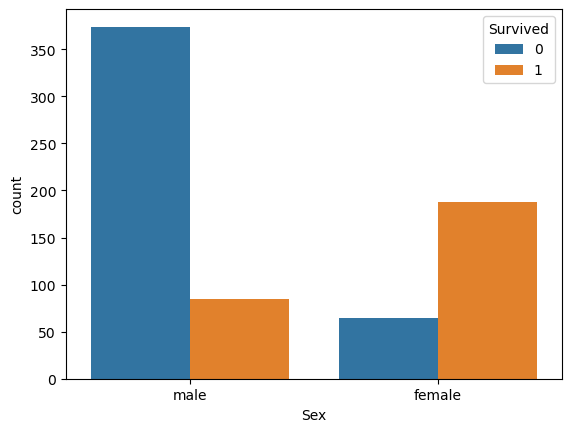

✅ [2.13] Benar! Aman!


In [72]:
ax = sns.countplot(data=train, x='Sex', hue='Survived')
plt.show()
cek('2.13', ax)

### Korelasi
Nilainya dari −1 sampai 1. Makin jauh dari 0, makin kuat hubungan **garis lurus**-nya. Minus artinya berlawanan arah (makin tinggi `Pclass`, makin kecil peluang selamat).

⚠️ Korelasi cuma untuk kolom **angka**. `Sex` (teks) tidak ikut dihitung, padahal kolom itu yang paling berpengaruh. Makanya groupby tetap penting.

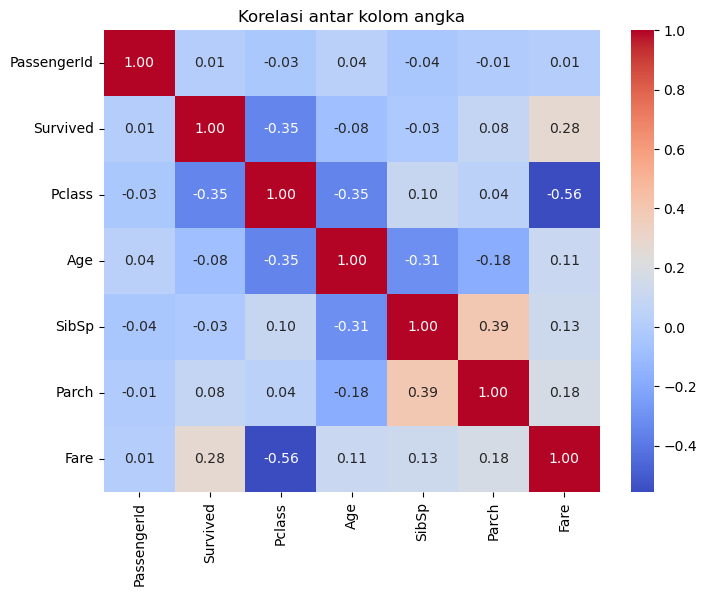

In [73]:
korelasi = train.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi antar kolom angka')
plt.show()

Petunjuk 1/2 untuk [2.14]: numeric_only=True supaya kolom teks diabaikan. Urut terbesar -> ascending=False.


**Latihan 2.14** — Ambil korelasi semua kolom angka dengan `Survived`, **urutkan dari terbesar**. Simpan ke `korelasi_target`.

In [93]:
korelasi_target = train.corr(numeric_only=1)['Survived'].sort_values(ascending=0)
cek('2.14', korelasi_target)
korelasi_target


✅ [2.14] Benar! Lanjut!


Survived       1.000000
Fare           0.275499
Parch          0.084178
PassengerId    0.011892
SibSp         -0.026115
Age           -0.084268
Pclass        -0.348007
Name: Survived, dtype: float64

## Tulis kesimpulan EDA
Di kompetisi (apalagi kalau notebook ikut dinilai), tulis 3–6 poin temuan. Contoh untuk data ini:
- `Cabin` kosong **77.5%** → buang, atau ubah jadi `HasCabin` (ada/tidak).
- `Age` kosong **19.2%** → isi median.
- `Embarked` kosong 2 baris → isi modus. `Fare` di **test** kosong 1 → isi median **train**.
- `Sex` sangat berpengaruh: peluang selamat perempuan **74%**, laki-laki **18.5%**. `Pclass` juga (kelas 1: 65%, kelas 3: 24%).
- `Name`, `Ticket`, `PassengerId` hampir semua unik → buang (atau ambil gelar Mr/Mrs/Miss dari `Name`).
- `Fare` miring kanan dengan banyak outlier. Random Forest aman; untuk model linear pertimbangkan `np.log1p`.

## 🧠 Tantangan tanpa titik-titik
Jangan scroll ke atas. Tulis dari ingatan.

In [88]:
hint('2.16')

Petunjuk 1/2 untuk [2.16]: groupby bisa dua kolom sekaligus: groupby(['Sex', 'Pclass']).


**Latihan 2.15** — Cari **nama kolom** dengan persentase missing **terbesar**. Simpan (sebagai teks) ke `kolom_paling_kosong`.

In [81]:
kolom_paling_kosong = train.isnull().mean().idxmax()
cek('2.15', kolom_paling_kosong)

✅ [2.15] Benar! Nah, gitu!


**Latihan 2.16** — Hitung peluang selamat per **kombinasi** `Sex` dan `Pclass` (groupby dua kolom). Simpan ke `selamat_sex_kelas`.

In [89]:
selamat_sex_kelas = train.groupby(['Sex','Pclass'])['Survived'].mean()
cek('2.16', selamat_sex_kelas)

✅ [2.16] Benar! Mantap!


In [90]:
progres()

01 Pandas Dasar           9/15  ■ ■ ■ ■ ■ ■ ■ ■ ■ □ □ □ □ □ □
02 EDA                   16/16  ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■ ■
02b Uji Kertas Kosong     0/7   □ □ □ □ □ □ □
03 Preprocessing          0/10  □ □ □ □ □ □ □ □ □ □
04 Model & Submission     0/10  □ □ □ □ □ □ □ □ □ □

Total lulus: 25/58


**Selesai?** Istirahat 10 menit, lalu lanjut ke **02b_Hari1_Uji_Kertas_Kosong.ipynb**: EDA di data baru, dari ingatan.